In [1]:
pip install pycocotools


Note: you may need to restart the kernel to use updated packages.


In [17]:
# Import required libraries
import pandas as pd
import numpy as np
import torch
import os, gc
import urllib.request
import random
import glob
from datetime import datetime
import xml.etree.ElementTree as ET 
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import shutil as sl
from tqdm import tqdm
import path as Path
from sklearn.model_selection import train_test_split
from PIL import Image
import torch.optim as optim
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler 
from IPython.display import display

from torchmetrics.detection import IntersectionOverUnion
from torch import tensor

from torch.utils.data import WeightedRandomSampler, DataLoader
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from IPython.display import Image as Image_IP
from IPython.display import clear_output
from torchmetrics import Accuracy
from torchmetrics.detection.mean_ap import MeanAveragePrecision

clear_output()

In [18]:
NUM_FILES = 1500

In [19]:
PATH_DIR = '/kaggle/input/pascal-voc-2012/VOC2012/'
PATH_ANN = '/kaggle/input/pascal-voc-2012/VOC2012/Annotations/'
PATH_IMG = '/kaggle/input/pascal-voc-2012/VOC2012/JPEGImages/'
PATH_WORK = '/kaggle/working/'
if os.path.isdir("voc2010"):
    sl.rmtree("/kaggle/working/voc2010")

if not os.path.isdir("voc2010"):
    os.mkdir("voc2010")
    os.makedirs("/kaggle/working/voc2010/annotations/")
    os.makedirs("/kaggle/working/voc2010/images")
i = 0
for xml_file in tqdm(sorted(glob.glob(PATH_ANN+'2010*.xml'))):
    if i<NUM_FILES: i += 1
    else: break;
    sl.copy(xml_file, "/kaggle/working/voc2010/annotations/")
    img_file = xml_file[:30]+"VOC2012/JPEGImages/"+xml_file[-15:-3]+"jpg"
    sl.copy(img_file, "/kaggle/working/voc2010/images/")

 43%|████▎     | 1500/3503 [00:03<00:04, 436.46it/s]


In [20]:
BATCH_SIZE = 4

In [21]:
# Open DataFrame function.  
def df_open(df, x=0):
    print('\n', df.shape)
    display(df) if x<1 else display(df.head(x))

# Clearing the cuda cache.      
def clear_cuda():
    torch.cuda.empty_cache()
    gc.collect()
    x = gc.collect()
    del x

# Information function about NaN and duplicates.  
def inf(df, check=False):
    df.drop_duplicates(inplace=check) if check else False
    n = df.isnull().sum().sum()
    if n != 0:
        print("NaN:", n)
        display(df[df.isnull().any(axis=1)])
    else:
        print("NaN not detected")
    print("Duplicated: ", df.duplicated().sum())
    print("Rows × Cols:", df.shape, '\n')
    return None

In [22]:
def xml_to_csv(path = PATH_ANN):
    xml_list = []
    for xml_file in tqdm(sorted(glob.glob(path+'2010*.xml'))):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        file_name = root.find('filename').text
        internal = root.find('size')
        channels = int(internal.find('depth').text)
        width = int(internal.find('width').text) 
        height = int(internal.find('height').text)

        for obj in root.findall('object'):
            name = obj.find('name').text
            bbx = obj.find('bndbox')
            xmin = int(float(bbx.find('xmin').text))
            ymin = int(float(bbx.find('ymin').text))
            xmax = int(float(bbx.find('xmax').text))
            ymax = int(float(bbx.find('ymax').text))
            value = (file_name,
                     name,
                     width,
                     height,
                     xmin,
                     ymin,
                     xmax,
                     ymax
                     )
            xml_list.append(value)
    column_name = ['file', 'name', 'width', 'height',
                   'xmin', 'ymin', 'xmax', 'ymax']
    xml_df = pd.DataFrame(xml_list, columns=column_name)

    return xml_df

# Exporting data. 
xml_df = xml_to_csv("/kaggle/working/voc2010/annotations/")

# Save xml_df as voc2010.csv
xml_df.to_csv('voc2010.csv', index=None)
del xml_df

100%|██████████| 1500/1500 [00:00<00:00, 14611.79it/s]


In [23]:
df_voc = pd.read_csv('voc2010.csv')
# df_voc.to_csv('voc100_2010.csv', index=False)
df_open(df_voc, 5)
print("Number of object:", len(df_voc))
print("Number of images:", len(df_voc['file'].unique()))
inf(df_voc)


 (3524, 8)


,file,name,width,height,xmin,ymin,xmax,ymax
0,2010_000001.jpg,cat,500,333,123,13,341,313
1,2010_000001.jpg,chair,500,333,294,13,410,236
2,2010_000001.jpg,chair,500,333,418,198,500,290
3,2010_000001.jpg,chair,500,333,362,1,498,80
4,2010_000001.jpg,diningtable,500,333,1,219,500,333


Number of object: 3524
Number of images: 1500
NaN not detected
Duplicated:  0
Rows × Cols: (3524, 8) 



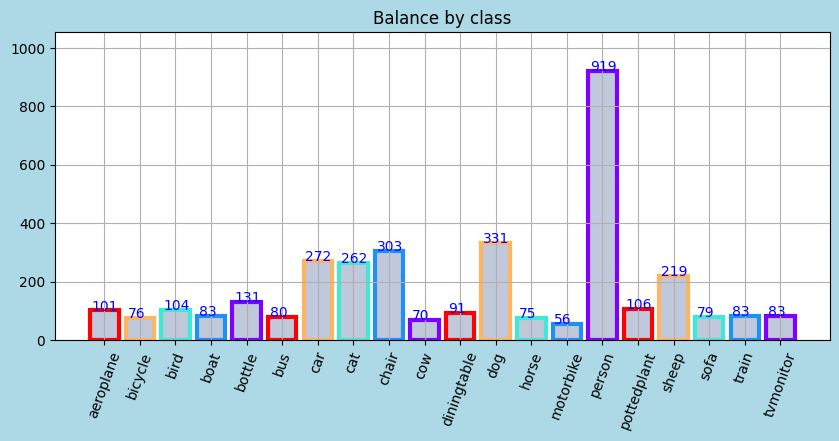

In [24]:
grp_class = df_voc.groupby('name')['xmin'].count()

grp_class = df_voc.groupby('name').count()['xmin']
colors = ['#FF0000','#FEB562','#3DEAD5','#1E91F3','#8000FF']
fig, ax = plt.subplots(figsize=(10,4), facecolor='lightblue')

ax.bar(grp_class.index, grp_class, color='#C0C8DB', linewidth=3.0, edgecolor=colors)
for i in range(len(df_voc['name'].unique())):
    ax.text(i-0.35, grp_class.iloc[i]+1, grp_class.iloc[i], color='#0000FF') # +70 all records
plt.xticks(rotation=70)
ax.set_ylim(0, grp_class.max()+round(grp_class.max()/np.log(grp_class.max()), 2))
plt.grid(True)
ax.set_title("Balance by class")
plt.show();

In [25]:
# Encoding for RCNN
rcnn_cod = {v: (idx+1) for idx, v in enumerate(sorted(df_voc['name'].unique()))}
df_voc['rcnn_class'] = df_voc['name'].replace(rcnn_cod)
df_voc['rcnn_class'] = df_voc['rcnn_class'].astype('int')

# Encoding for YOLO
yolo_cod = {v: (idx) for idx, v in enumerate(sorted(df_voc['name'].unique()))}
df_voc['yolo_class'] = df_voc['name'].replace(yolo_cod)
df_voc['yolo_class'] = df_voc['yolo_class'].astype('int')

df_open(df_voc,10)

# Preparing class dictionaries
rcnn_dict = {v:k for k, v in rcnn_cod.items()}
yolo_dict = {v:k for k, v in yolo_cod.items()}
print(rcnn_dict,'\n')
print(yolo_dict)


 (3524, 10)


<ipython-input-25-9a723f430ad3>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_voc['rcnn_class'] = df_voc['name'].replace(rcnn_cod)
<ipython-input-25-9a723f430ad3>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_voc['yolo_class'] = df_voc['name'].replace(yolo_cod)


,file,name,width,height,xmin,ymin,xmax,ymax,rcnn_class,yolo_class
0,2010_000001.jpg,cat,500,333,123,13,341,313,8,7
1,2010_000001.jpg,chair,500,333,294,13,410,236,9,8
2,2010_000001.jpg,chair,500,333,418,198,500,290,9,8
3,2010_000001.jpg,chair,500,333,362,1,498,80,9,8
4,2010_000001.jpg,diningtable,500,333,1,219,500,333,11,10
5,2010_000001.jpg,diningtable,500,333,1,1,234,188,11,10
6,2010_000002.jpg,sheep,500,430,102,46,411,400,17,16
7,2010_000003.jpg,dog,500,375,160,156,344,307,12,11
8,2010_000003.jpg,chair,500,375,17,52,455,375,9,8
9,2010_000009.jpg,cat,500,333,160,30,345,312,8,7


{1: 'aeroplane', 2: 'bicycle', 3: 'bird', 4: 'boat', 5: 'bottle', 6: 'bus', 7: 'car', 8: 'cat', 9: 'chair', 10: 'cow', 11: 'diningtable', 12: 'dog', 13: 'horse', 14: 'motorbike', 15: 'person', 16: 'pottedplant', 17: 'sheep', 18: 'sofa', 19: 'train', 20: 'tvmonitor'} 

{0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle', 5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow', 10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike', 14: 'person', 15: 'pottedplant', 16: 'sheep', 17: 'sofa', 18: 'train', 19: 'tvmonitor'}


In [26]:
(name, class_counts) = np.unique(df_voc['name'], return_counts=True)
name, sample_weights = name, [round(1-c/sum(class_counts), 5) for c in class_counts]


df_voc['weight_f'] = df_voc['name'].replace(dict(zip(name, sample_weights)))
df_voc['weight_f'] = (df_voc.groupby('file')['weight_f'].transform('mean'))
df_voc['weight_s'] = (df_voc['weight_f'].astype(str).apply(lambda x: x[:3]))
df_open(df_voc,10)


 (3524, 12)


<ipython-input-26-88d7f36c03ee>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_voc['weight_f'] = df_voc['name'].replace(dict(zip(name, sample_weights)))


,file,name,width,height,xmin,ymin,xmax,ymax,rcnn_class,yolo_class,weight_f,weight_s
0,2010_000001.jpg,cat,500,333,123,13,341,313,8,7,0.936012,0.9
1,2010_000001.jpg,chair,500,333,294,13,410,236,9,8,0.936012,0.9
2,2010_000001.jpg,chair,500,333,418,198,500,290,9,8,0.936012,0.9
3,2010_000001.jpg,chair,500,333,362,1,498,80,9,8,0.936012,0.9
4,2010_000001.jpg,diningtable,500,333,1,219,500,333,11,10,0.936012,0.9
5,2010_000001.jpg,diningtable,500,333,1,1,234,188,11,10,0.936012,0.9
6,2010_000002.jpg,sheep,500,430,102,46,411,400,17,16,0.937850,0.9
7,2010_000003.jpg,dog,500,375,160,156,344,307,12,11,0.910045,0.9
8,2010_000003.jpg,chair,500,375,17,52,455,375,9,8,0.910045,0.9
9,2010_000009.jpg,cat,500,333,160,30,345,312,8,7,0.925650,0.9


In [27]:
X = df_voc[['file', 'weight_s']].drop_duplicates()
y =  X['weight_s']

train, test = train_test_split(X, train_size=0.8, stratify=y, random_state=42)
valid, test2 = train_test_split(test, train_size=0.8, random_state=42)
train_df = (df_voc[df_voc['file'].isin(train['file'])].copy())
valid_df = (df_voc[df_voc['file'].isin(valid['file'])].copy())
test_df = (df_voc[df_voc['file'].isin(test2['file'])].copy())
df_open(train_df,3)
df_open(valid_df,3)
df_open(test_df,3)



 (2837, 12)


,file,name,width,height,xmin,ymin,xmax,ymax,rcnn_class,yolo_class,weight_f,weight_s
0,2010_000001.jpg,cat,500,333,123,13,341,313,8,7,0.936012,0.9
1,2010_000001.jpg,chair,500,333,294,13,410,236,9,8,0.936012,0.9
2,2010_000001.jpg,chair,500,333,418,198,500,290,9,8,0.936012,0.9



 (551, 12)


,file,name,width,height,xmin,ymin,xmax,ymax,rcnn_class,yolo_class,weight_f,weight_s
27,2010_000026.jpg,dog,500,375,119,12,425,375,12,11,0.90607,0.9
35,2010_000033.jpg,dog,500,333,83,9,377,306,12,11,0.90607,0.9
52,2010_000055.jpg,person,500,375,21,68,500,375,15,14,0.73922,0.7



 (136, 12)


,file,name,width,height,xmin,ymin,xmax,ymax,rcnn_class,yolo_class,weight_f,weight_s
50,2010_000053.jpg,tvmonitor,500,375,61,57,498,320,20,19,0.97645,0.9
120,2010_000113.jpg,bicycle,500,375,107,7,466,317,2,1,0.97843,0.9
211,2010_000202.jpg,pottedplant,375,500,1,1,374,499,16,15,0.96992,0.9


In [28]:
transforms_train = A.Compose([
    A.HorizontalFlip(),
    A.OneOf([
        A.ColorJitter(hue=0.1),
        A.Equalize(by_channels=False),
        A.FancyPCA(),
        A.GaussNoise(),
        A.ImageCompression(),
        A.ISONoise(),
        A.RandomGamma(),
        A.RandomToneCurve(),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15),
        A.AdvancedBlur(p=0.1)
    ]),
    ToTensorV2()
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc', label_fields=['labels'], min_area=21))

transforms_valid = ToTensorV2()

In [29]:
class VOC_2010(torch.utils.data.Dataset):
    def __init__(self, df, imdir, transforms):
        self.df = df
        self.imdir = imdir
        self.imnames = df['file'].unique()
        self.transforms = transforms
    
    def __getitem__(self, idx):
        imname = self.imnames[idx]
        image = cv2.imread(os.path.join(self.imdir+imname), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #.astype(np.float32)
                        
        # Augmentation 
        mask = self.df['file'] == imname
        bboxes = np.array(self.df[mask][['xmin', 'ymin', 'xmax', 'ymax']])
        labels = np.array((self.df[mask]['rcnn_class']))
        transformed = self.transforms(image=image, bboxes=bboxes, labels=labels)
                        
        # Output for the model 
        image = transformed['image'] 
        bboxes = torch.as_tensor(transformed['bboxes'], dtype=torch.float16)
        labels = torch.as_tensor(labels, dtype=torch.int64)        
        target = {'boxes': bboxes, 'labels': labels}
                        
        # Normalization
        image = image/255
               
        return image, target
    
    
    def __len__(self):
        return len(self.imnames)

In [30]:
img_dir = "/kaggle/working/voc2010/images/"

train_data = VOC_2010(train_df, img_dir, transforms_train)
valid_data = VOC_2010(valid_df, img_dir, transforms_valid)



print('Training sample size', len(train_data))
print('Validation sample size', len(valid_data))

Training sample size 1200
Validation sample size 240


In [31]:
# Weights
train_whs = torch.as_tensor(np.array(train_df.drop_duplicates(subset='file')['weight_f']), dtype=torch.float16)

valid_whs = torch.as_tensor(np.array(valid_df.drop_duplicates(subset='file')['weight_f']), dtype=torch.float16)

train_sampler = WeightedRandomSampler(train_whs, len(train_whs))
valid_sampler = WeightedRandomSampler(valid_whs, len(valid_whs))

In [32]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataloader = DataLoader(
    train_data, 
    sampler=train_sampler, 
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn
    )

valid_dataloader = DataLoader(
    valid_data, 
    sampler=valid_sampler, 
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
    )

# DataLoader for measuring metrics.  
metrics_dataloader = DataLoader(
    valid_data,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn
)

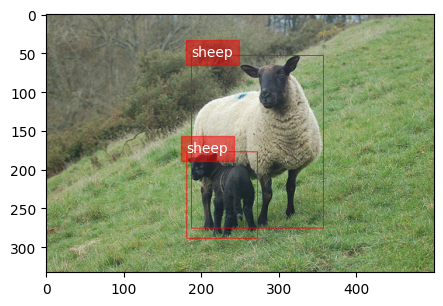

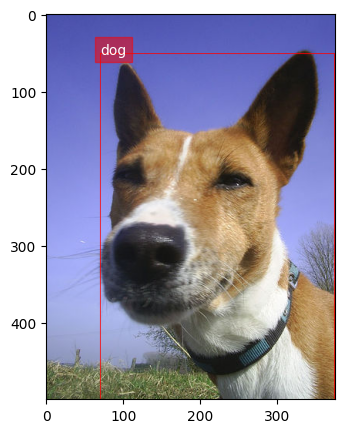

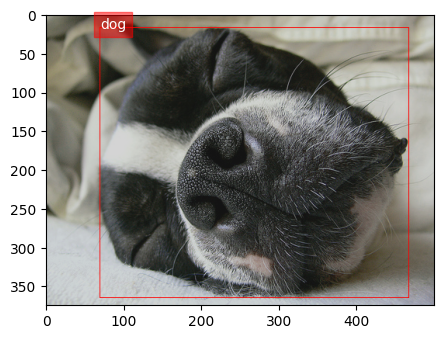

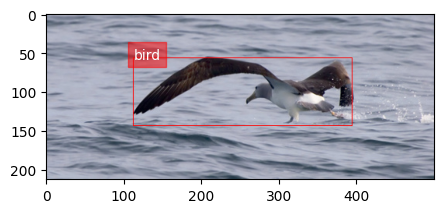

In [33]:
def image_convert(image):
    image = image.clone().cpu().numpy()
    image = image.transpose((1,2,0))
    image = (image * 255).astype(np.uint8)
    return image

def plot_img(data):
    img = next(iter(data))
    for num in range(BATCH_SIZE):
        image = image_convert(img[0][num])
        image = np.ascontiguousarray(image)
        bboxes = img[1][num]['boxes'].numpy()
        labels = img[1][num]['labels']
        fig, ax = plt.subplots(figsize=(5,5))
        
        for i, bbox in enumerate(bboxes):
            xmin, ymin, xmax, ymax = (int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3]))
            cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), thickness=1)
            text = ax.text(xmin, ymin, f'{rcnn_dict[int(str(labels[i])[7:-1])]}', fontsize=10, color='w')
            text.set_bbox(dict(facecolor='r', alpha=0.5, edgecolor='r'))
        plt.imshow(image);
    
plot_img(train_dataloader)

In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# We use a pre-trained Resnet-50 model.
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
num_classes = len(class_counts)


in_features = model.roi_heads.box_predictor.cls_score.in_features


model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes+1)
print(f'\nDevice: {device}, number of classes: {num_classes}, pretrained model: Resnet-50')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 208MB/s] 



Device: cuda, number of classes: 20, pretrained model: Resnet-50


In [35]:
# Model training function.
def calc(model, optimizer, dataloader, scheduler):
    scheduler = scheduler
    model.train()
    def sub_calc(dataloader, scheduler, is_train=True, mode='train'):
        loss, indx = [], 0
        torch.set_grad_enabled(is_train)
    
        for i, (images, targets) in tqdm(enumerate(dataloader)):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            loss.append(losses.item())
            if is_train:
                optimizer.zero_grad()
                losses.backward()
                optimizer.step()
        scheduler.step() if is_train else scheduler
        return round(np.mean(loss), 4)
    return sub_calc(train_dataloader, scheduler, True, 'train'), sub_calc(valid_dataloader, scheduler, False, 'valid')

In [37]:
model.to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0005, momentum=0.7, weight_decay=0.0005)
scheduler = optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0003, max_lr=0.01,step_size_up=5,mode="exp_range",gamma=0.85)

In [38]:
# Start training.
num_epochs = 15
total_train_loss = []
total_valid_loss = []
total_epochs = []
best_model = 1000
start = datetime.now()
for epoch in range(num_epochs):
    print(f'There is a calculation of {epoch+1} epoch out of {num_epochs}.\
    Please wait...', end='\r')
    train_loss, valid_loss = calc(model, optimizer, train_dataloader, scheduler)
    total_train_loss.append(train_loss)
    total_valid_loss.append(valid_loss)
    total_epochs.append(epoch+1)
    if valid_loss < best_model:
        best_model = valid_loss
        path_best = f"ep{str(epoch+1)}_best_model.pth"
        torch.save(model.state_dict(), path_best)
    
    print('')
end = datetime.now()
print("Runtime Faster RCNN:",str(end-start)[:7])

300it [03:15,  1.53it/s]
60it [00:19,  3.12it/s]


300it [03:15,  1.54it/s]
60it [00:18,  3.23it/s]


300it [03:17,  1.52it/s]
60it [00:18,  3.31it/s]


300it [03:13,  1.55it/s]
60it [00:18,  3.18it/s]


300it [03:17,  1.52it/s]
60it [00:18,  3.21it/s]


...

300it [03:18,  1.52it/s]
60it [00:18,  3.20it/s]


300it [03:15,  1.53it/s]
60it [00:17,  3.34it/s]


300it [03:17,  1.52it/s]
60it [00:18,  3.24it/s]


300it [03:17,  1.52it/s]
60it [00:18,  3.25it/s]


Runtime Faster RCNN: 0:53:50


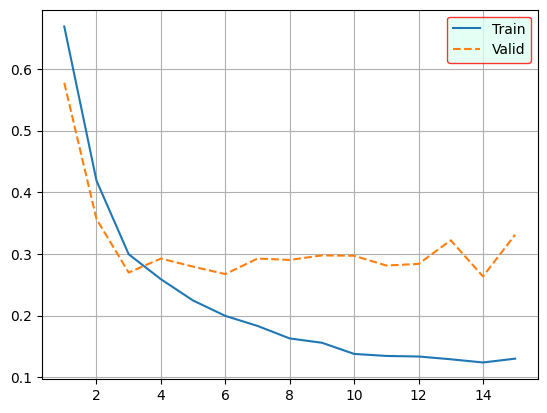

In [39]:
# epoch = range(1,21,1)
plt.plot(total_epochs, total_train_loss, label='Train')
plt.plot(total_epochs, total_valid_loss, label='Valid', linestyle='--')
plt.grid(True)
plt.legend(loc=1, frameon=True, edgecolor='red', facecolor='#DEFFF2')
plt.show();

In [41]:
del model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
num_classes = len(np.unique(df_voc['rcnn_class'])) 
print(f'Число классов: {num_classes}')
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes+1)
model.load_state_dict(torch.load('/kaggle/working/ep14_best_model.pth'))

cuda
Число классов: 20


<ipython-input-41-3320caccd106>:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/kaggle/working/ep14_best_model.pth'))


<All keys matched successfully>

In [42]:
# Threshold for low confidence block filter.  
PIP_th = 0.5

# Threshold for the non-maximum block suppression filter (torch.nms).  
IOU_th = 0.7

In [43]:
# Function for filtering blocks with a low level of confidence. 
def filt_box(f_data, pip_th):
    data_p = f_data.copy()
    main_lst = []
    
    for idx, val in enumerate(f_data['scores']):
        if val > pip_th:
            main_lst.append(idx)
    for i in list(data_p.keys()):
        data_p[i] = data_p[i][main_lst]
    return data_p

# Function for non-maximum block suppression (Torch.nms).  
def filt_nms(f_data, iou_th):
    main_idx = torchvision.ops.nms(f_data['boxes'], f_data['scores'], iou_th)
    final_pr = f_data

    for i in list(f_data.keys()):
        final_pr[i] = final_pr[i][main_idx]
    return final_pr


# Filtering, prediction and data management function for mAP.  
def proc_p(model, img, pip_th, iou_th, num, images=0):
    if images == 0:
        model = model.to('cpu')
        model.eval()
        with torch.no_grad():
            model_p = model(img[0])
        f_pip = filt_box(model_p[num], pip_th)
        f_pred = filt_nms(f_pip, iou_th)
        return f_pred['boxes'], f_pred['labels'], f_pred['scores']*100
    else:
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            model_p = model(images)
        model_p = list({key: val.to('cpu') for key, val in pred.items()} for pred in model_p)
        f_pip = list(filt_box(pred, 0.45) for pred in model_p)
        f_pred = list(filt_nms(pred, 7) for pred in f_pip)
        return f_pred

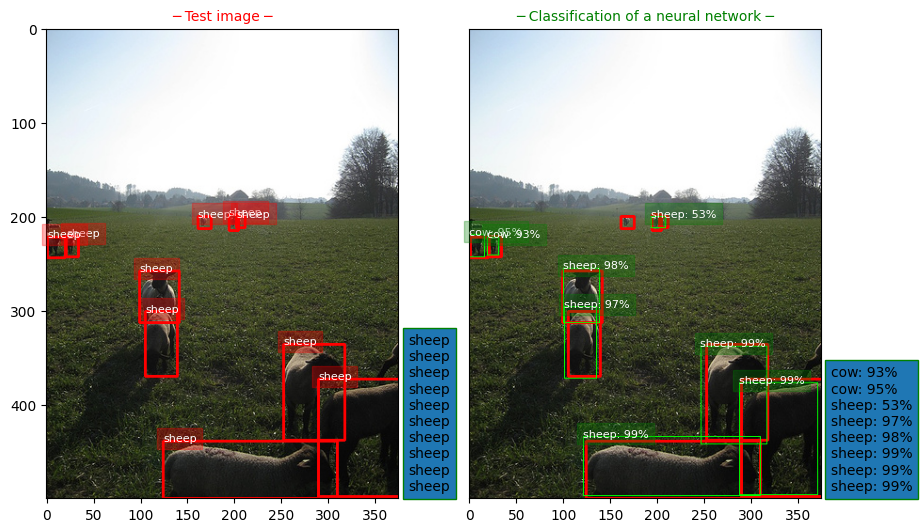

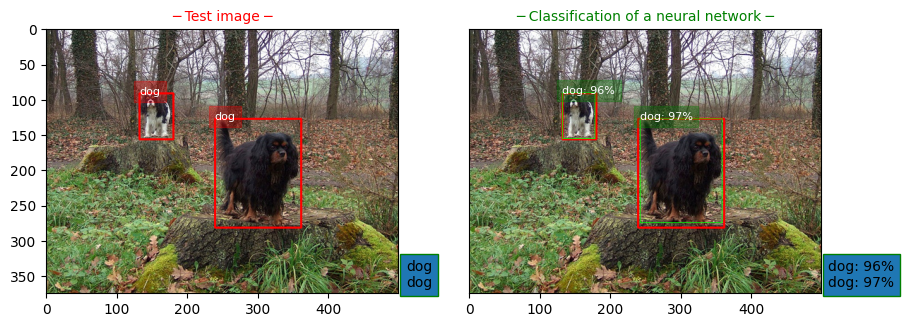

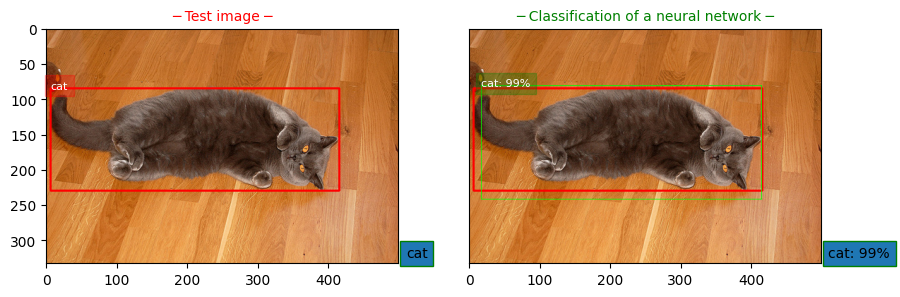

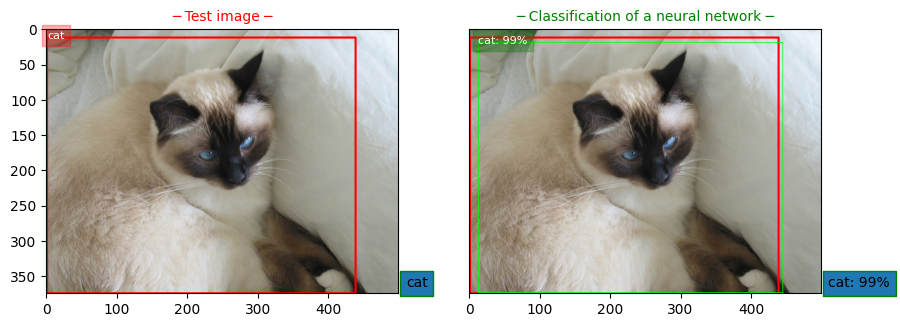

In [44]:
# Construction of drawings. 
def pict_predict(model,data, batch):
    img = next(iter(data))
    for num in range(batch):
        image = image_convert(img[0][num])
        image = np.ascontiguousarray(image)
        bboxes = img[1][num]['boxes'].numpy()
        labels = img[1][num]['labels']
        bboxes_p, labels_p, scores_p = proc_p(model, img, PIP_th, IOU_th, num, 0)
        iter_box=[]
        iter_box.append(bboxes)
        iter_box.append(bboxes_p)
        fig, axes = plt.subplots(1, 2, figsize=(10,7))
        txt, txt_p = [], []
        
        for n in range(2):
            for i, vol in enumerate(iter_box[n]):
                xmin, ymin, xmax, ymax = (int(vol[0]), int(vol[1]), int(vol[2]), int(vol[3]))
                if n == 0:
                    coler, clr,t_ness = (255,0,0), 'r', 2
                    txt.append(rcnn_dict[int(str(labels[i])[7:-1])])
                    text = axes[n].text(xmin, ymin, f'{rcnn_dict[int(str(labels[i])[7:-1])]}', fontsize=8, color='w')
                if n == 1:
                    coler, clr, t_ness = (0,255,0), 'g', 1
                    txt_p.append(f"{rcnn_dict[int(str(labels_p[i])[7:-1])]}: {int(scores_p[i])}%")
                    text = axes[n].text(xmin, ymin, f'{rcnn_dict[int(str(labels_p[i])[7:-1])]}: {int(scores_p[i])}%', fontsize=8, color='w')
                cv2.rectangle(image, (xmin, ymin), (xmax, ymax), coler, thickness=t_ness)
                text.set_bbox(dict(facecolor=clr, alpha=0.3, edgecolor=clr))
                
            x = str(sorted(txt))[1:-1].replace("'", "")
            xn  = x.replace(", ", "\n")
            y = str(sorted(txt_p))[1:-1].replace("'", "")
            yn  = y.replace(", ", "\n")
            if n == 0:
                axes[0].set_title('─ Test image ─',c=clr, fontsize=10)
                axes[0].text(image.shape[1]+10, image.shape[0]-9.3, xn, bbox={'edgecolor':'green'})
            else:
                axes[1].set_title("─ Classification of a neural network ─", c='g', fontsize=10)
                axes[1].text(image.shape[1]+10, image.shape[0]-9.3, yn, bbox={'edgecolor':'green'})
                plt.yticks([])
            
            axes[n].imshow(image)

pict_predict(model, valid_dataloader, BATCH_SIZE)

In [45]:
# The trained model performs the classification.  
final_pred, final_targ = [], []
for images, targets in tqdm(metrics_dataloader):
    images = list(image.to(device) for image in images)
    targets = list(targets)
    f_pred = proc_p(model, final_pred, PIP_th, IOU_th, 0, images=images)

    final_targ.extend(targets)
    final_pred.extend(f_pred)

100%|██████████| 60/60 [00:18<00:00,  3.26it/s]


In [46]:
# Class preparation function.  
def preparing_class():
    pred_lab, targ_lab = [], []
    l_pred, l_targ = [], []

    # Creating class lists.  
    for i in range(len(final_pred)):
        pred_lab.extend([final_pred[i]['labels']])
        targ_lab.extend([final_targ[i]['labels']])

    # Balancing class lists.  
    for i in range(len(pred_lab)):
        len_pred = len(pred_lab[i])
        len_targ = len(targ_lab[i])
        if len_pred == 1:
            l_pred.append([pred_lab[i].squeeze().tolist()])
        else:
            l_pred.extend([pred_lab[i].squeeze().tolist()])
        if len_targ == 1:
            l_targ.append([targ_lab[i].squeeze().tolist()])
        else:
            l_targ.extend([targ_lab[i].squeeze().tolist()])
        if len_pred > len_targ:
            l_targ[i].extend([0]*abs(len_pred-len_targ))
        elif len_pred < len_targ:
            l_pred[i].extend([0]*abs(len_targ-len_pred))

    for i in range(len(l_pred)):
        if len(l_pred[i])!=len(l_targ[i]):
            print(i, l_pred[i], l_targ[i])

    # Processing sublists with one class.  
    for i in range(len(l_targ)):
        if len(l_targ[i])==1:
            l_targ[i].append(0)
        if len(l_pred[i])==1:
            l_pred[i].append(0)
    return l_pred, l_targ

In [47]:
iou_lst, acc_lst = [], []
l_pred, l_targ = preparing_class()



In [48]:
from torchmetrics.detection import MeanAveragePrecision

# Compute mAP for Faster R-CNN
mAP = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
mAP.update(final_pred, final_targ)
map_50 = mAP.compute()["map_50"].item()  # Pascal VOC metric
map_50_95 = mAP.compute()["map"].item()  # COCO metric

print(f"Faster R-CNN mAP@0.5: {map_50:.4f}")
print(f"Faster R-CNN mAP@0.5:0.95: {map_50_95:.4f}")


Faster R-CNN mAP@0.5: 0.6711
Faster R-CNN mAP@0.5:0.95: 0.4236


In [49]:
iou_thresholds = [0.3, 0.5, 0.7]  # Different IoU thresholds to test
iou_results = {}

for iou in iou_thresholds:
    final_pred_iou = [filt_nms(filt_box(pred, PIP_th), iou) for pred in final_pred]
    mAP = MeanAveragePrecision(iou_type="bbox")
    mAP.update(final_pred_iou, final_targ)
    iou_results[iou] = mAP.compute()["map_50"].item()

print("Faster R-CNN IoU Analysis:", iou_results)


Faster R-CNN IoU Analysis: {0.3: 0.6267598271369934, 0.5: 0.6507426500320435, 0.7: 0.6598107218742371}


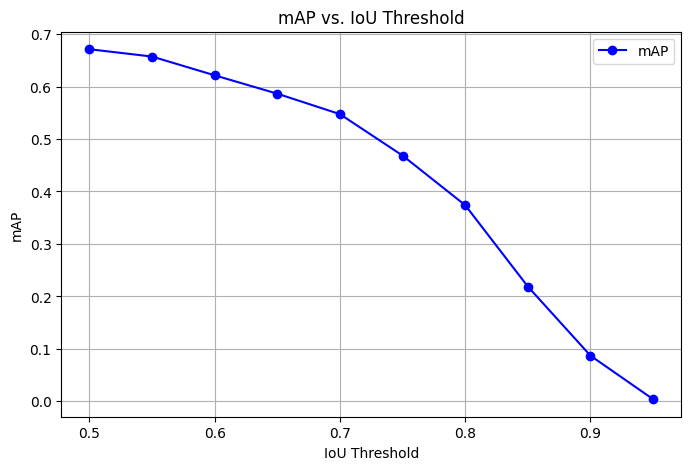

In [50]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchmetrics.detection import MeanAveragePrecision

# Define IoU thresholds (0.5 to 0.95 in steps of 0.05)
iou_thresholds = np.arange(0.5, 1.0, 0.05)
map_scores = []

# Compute mAP for different IoU thresholds
for iou_th in iou_thresholds:
    mAP = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[iou_th])
    mAP.update(final_pred, final_targ)
    map_scores.append(mAP.compute()["map"].item())

# Plot mAP vs. IoU Threshold
plt.figure(figsize=(8, 5))
plt.plot(iou_thresholds, map_scores, marker="o", linestyle="-", color="b", label="mAP")
plt.xlabel("IoU Threshold")
plt.ylabel("mAP")
plt.title("mAP vs. IoU Threshold")
plt.grid(True)
plt.legend()
plt.show()


In [51]:
import time

num_images = len(metrics_dataloader)
total_time = 0

for images, _ in metrics_dataloader:
    images = [img.to(device) for img in images]
    start_time = time.time()
    _ = model(images)
    total_time += (time.time() - start_time)

avg_time_per_image = total_time / num_images
fps = 1 / avg_time_per_image

print(f"Faster R-CNN Avg Inference Time: {avg_time_per_image:.4f} sec")
print(f"Faster R-CNN FPS: {fps:.2f}")


Faster R-CNN Avg Inference Time: 0.2789 sec
Faster R-CNN FPS: 3.59


In [54]:
mAP = MeanAveragePrecision(class_metrics=True)
mAP.update(final_pred, final_targ)
map_s = str(mAP.compute()['map'])[7:-1]
clear_output()
map_50 = str(mAP.compute()['map_50'])[7:-1]

# Accuracy calculation.  
for i in range(len(final_pred)):
    target = tensor(l_targ[i])
    preds = tensor(l_pred[i])
    accuracy = Accuracy(task="multiclass", num_classes=len(l_targ[i]))
    x = accuracy(preds, target)
    acc_lst.append(x*100)

total_acc = np.mean(acc_lst)/100

print(f"This model provides:\n mAP: {map_s}\n mAP-50: {map_50}\n\
 Total accuracy: {total_acc:.2%}%")

This model provides:
 mAP: 0.4236
 mAP-50: 0.6711
 Total accuracy: 60.06%%


In [55]:
mAP = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
mAP.update(final_pred, final_targ)
classwise_map = mAP.compute()["map_per_class"]

for i, score in enumerate(classwise_map):
    print(f"Class {i}: mAP@0.5 = {score:.4f}")


Class 0: mAP@0.5 = 0.5544
Class 1: mAP@0.5 = 0.5033
Class 2: mAP@0.5 = 0.4227
Class 3: mAP@0.5 = 0.3467
Class 4: mAP@0.5 = 0.2340
Class 5: mAP@0.5 = 0.5166
Class 6: mAP@0.5 = 0.4731
Class 7: mAP@0.5 = 0.5290
Class 8: mAP@0.5 = 0.3272
Class 9: mAP@0.5 = 0.2826
Class 10: mAP@0.5 = 0.4062
Class 11: mAP@0.5 = 0.4795
Class 12: mAP@0.5 = 0.4476
Class 13: mAP@0.5 = 0.5510
Class 14: mAP@0.5 = 0.4931
Class 15: mAP@0.5 = 0.1595
Class 16: mAP@0.5 = 0.5477
Class 17: mAP@0.5 = 0.2170
Class 18: mAP@0.5 = 0.5071
Class 19: mAP@0.5 = 0.4728


In [56]:
!git clone https://github.com/ultralytics/yolov5  # clone
os.chdir("yolov5")
!pip install -qr requirements.txt  # install

import utils
display = utils.notebook_init()  # checks

YOLOv5 🚀 v7.0-411-gf4d8a84c Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)


Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6170.2/8062.4 GB disk)


In [57]:
os.chdir(PATH_WORK+"yolov5")

if os.path.isdir("dataset"):
    sl.rmtree("dataset")
    
if not os.path.isdir("yolov5/dataset"):
    os.mkdir("dataset")
    os.makedirs("dataset/train/images/")
    os.makedirs("dataset/train/labels/")
    os.makedirs("dataset/valid/images")
    os.makedirs("dataset/valid/labels")
    os.makedirs("dataset/test/images")
    os.makedirs("dataset/test/labels")

In [58]:
def copy_img(data, fold_name):
    df_lst = data.file.to_list()
    for file_n in tqdm(df_lst):
        img = Image.open(PATH_WORK+"voc2010/images/"+file_n)
        img_out = img.resize((640, 480))
        _ = img_out.save("dataset/"+fold_name+"/images/"+file_n)
        
copy_img(train_df, "train")
copy_img(valid_df, "valid")
copy_img(test_df, "test")

100%|██████████| 136/136 [00:01<00:00, 104.53it/s]


In [59]:
def convert(data):
    df = data.copy()
    df['xmax'] = (640/df['width'])*df['xmax']
    df['ymax'] = (480/df['height'])*df['ymax']
    df['xmin'] = (640/df['width'])*df['xmin']
    df['ymin'] = (480/df['height'])*df['ymin']

    df[['xmax', 'ymax', 'xmin', 'ymin']] = df[['xmax', 'ymax', 'xmin', 'ymin']].astype('int64')

    df['x_center'] = (df['xmax']+df['xmin'])/(2*640)
    df['y_center'] = (df['ymax']+df['ymin'])/(2*480)
    df['box_width'] = (df['ymax']-df['ymin'])/(480)
    df['box_height'] = (df['xmax']-df['xmin'])/(640)

    df = df.astype('string')
    return df

df = convert(df_voc).copy()

In [60]:
def create_labels(image_list, data_name):
    name_lst = image_list.file.to_list()
    for name in tqdm(name_lst):
        data = df[df['file']==name]
        box_list = []
        for index in range(len(data)):
            row = data.iloc[index]
            box_list.append(row['yolo_class']+" "+row["x_center"]+" "+row["y_center"]\
                        +" "+row["box_width"]+" "+row["box_height"])
            
        text = "\n".join(box_list)
        with open("dataset/"+data_name+"/labels/"+name[:-4] +".txt", "w") as file:
            file.write(text)

create_labels(train_df, "train")
create_labels(valid_df, "valid")
create_labels(test_df, "test")

100%|██████████| 136/136 [00:00<00:00, 566.65it/s]


In [61]:
yaml_text = """
train: dataset/train/images
val: dataset/valid/images

nc: 20

names: 
  0: aeroplane
  1: bicycle
  2: bird
  3: boat
  4: bottle
  5: bus
  6: car
  7: cat
  8: chair
  9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor
"""

with open("dataset/data.yaml", 'w') as file:
    file.write(yaml_text)

In [62]:
start = datetime.now()

!python train.py \
--img 640 \
--cfg models/yolov5m.yaml \
--hyp data/hyps/hyp.VOC.yaml \
--batch 4 \
--epochs 15 \
--data /kaggle/working/yolov5/dataset/data.yaml \
--weights yolov5m.pt \
--name test_result \
--device 0

end = datetime.now()


2025-04-02 19:45:56.550717: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-02 19:45:56.737247: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-02 19:45:56.794185: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
train: weights=yolov5m.pt, cfg=models/yolov5m.yaml, data=/kaggle/working/yolov5/dataset/data.yaml, hyp=data/hyps/hyp.VOC.yaml, epochs=15, batch_size=4, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=0, 

In [63]:
print("Runtime:",str(end-start)[:7])

Runtime: 0:14:57


In [64]:
!python detect.py --weights yolov5x6.pt \
--img 640 \
--conf 0.25 \
--source dataset/test/images

detect: weights=['yolov5x6.pt'], source=dataset/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-411-gf4d8a84c Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)

100%|█████████████████████████████████████████| 270M/270M [00:01<00:00, 246MB/s]

Fusing layers... 
YOLOv5x6 summary: 574 layers, 140730220 parameters, 0 gradients, 209.6 GFLOPs
image 1/60 /kaggle/working/yolov5/dataset/test/images/2010_000053.jpg: 512x640 1 tv, 46.2ms
image 2/60 /kaggle/working/yolov5/dataset/test/images/2010_000113.jpg: 512x640 1 bicycle, 35.2ms
image 3/60 /kaggle/working/yolov5/dataset/te

In [65]:
import time

start_time = time.time()
!python detect.py --weights yolov5x6.pt --img 640 --conf 0.25 --source dataset/test/images
end_time = time.time()

num_images = len(os.listdir("dataset/test/images"))
avg_time_per_image = (end_time - start_time) / num_images
fps = 1 / avg_time_per_image

print(f"YOLOv5 Avg Inference Time: {avg_time_per_image:.4f} sec")
print(f"YOLOv5 FPS: {fps:.2f}")


detect: weights=['yolov5x6.pt'], source=dataset/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-411-gf4d8a84c Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)

Fusing layers... 
YOLOv5x6 summary: 574 layers, 140730220 parameters, 0 gradients, 209.6 GFLOPs
image 1/60 /kaggle/working/yolov5/dataset/test/images/2010_000053.jpg: 512x640 1 tv, 46.6ms
image 2/60 /kaggle/working/yolov5/dataset/test/images/2010_000113.jpg: 512x640 1 bicycle, 35.1ms
image 3/60 /kaggle/working/yolov5/dataset/test/images/2010_000202.jpg: 512x640 (no detections), 35.0ms
image 4/60 /kaggle/work

In [66]:
!python detect.py --weights yolov5x6.pt \
--img 640 \
--conf 0.25 \
--iou-thres 0.3 \
--source dataset/test/images

!python detect.py --weights yolov5x6.pt \
--img 640 \
--conf 0.25 \
--iou-thres 0.5 \
--source dataset/test/images

!python detect.py --weights yolov5x6.pt \
--img 640 \
--conf 0.25 \
--iou-thres 0.7 \
--source dataset/test/images


detect: weights=['yolov5x6.pt'], source=dataset/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.3, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-411-gf4d8a84c Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)

Fusing layers... 
YOLOv5x6 summary: 574 layers, 140730220 parameters, 0 gradients, 209.6 GFLOPs
image 1/60 /kaggle/working/yolov5/dataset/test/images/2010_000053.jpg: 512x640 1 tv, 46.0ms
image 2/60 /kaggle/working/yolov5/dataset/test/images/2010_000113.jpg: 512x640 1 bicycle, 35.3ms
image 3/60 /kaggle/working/yolov5/dataset/test/images/2010_000202.jpg: 512x640 (no detections), 35.1ms
image 4/60 /kaggle/worki

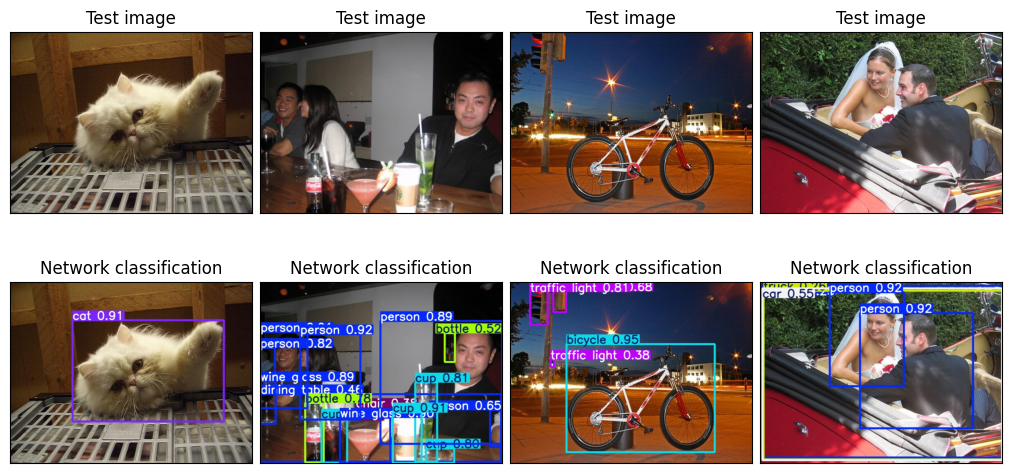

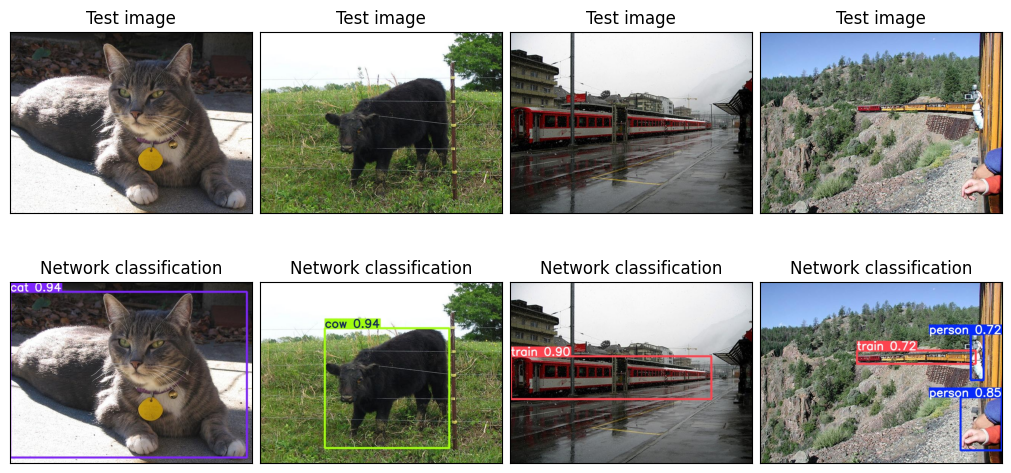

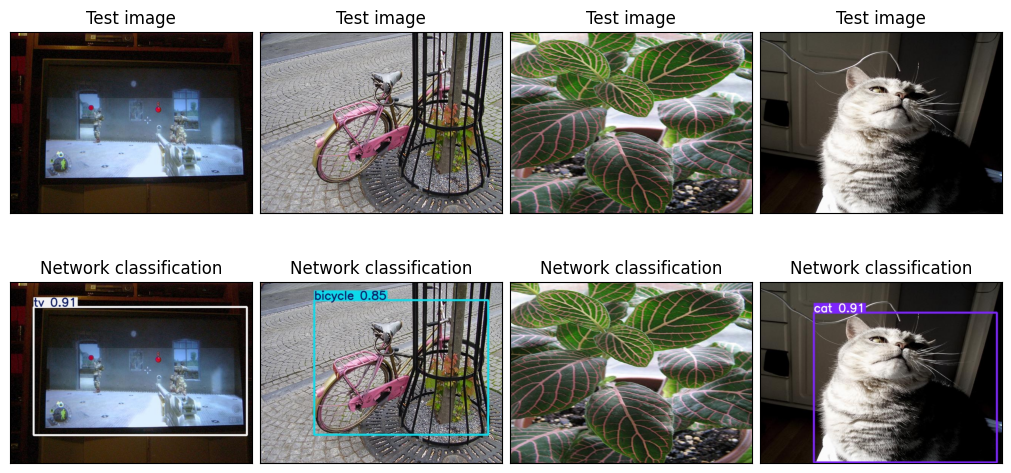

In [67]:
def plt_show(n):
    name_lst = list(np.unique(test_df.file))
    n=0 if n<0 else n
    n=len(name_lst)-4 if n>len(name_lst)-4 else n
    s = n+4
    fig, (ax1,ax2) = plt.subplots(2, 4, figsize = (10,5), constrained_layout = True)

    for i, row in enumerate(name_lst[n:s]):
        ax1[i].imshow(plt.imread('dataset/test/images/'+row))
        ax1[i].set_xticks([])
        ax1[i].set_yticks([])
        ax1[i].set_title('Test image')
        ax2[i].imshow(plt.imread('runs/detect/exp/' +row))
        ax2[i].set_xticks([])
        ax2[i].set_yticks([])
        ax2[i].set_title('Network classification')
    plt.show()

plt_show(5)
plt_show(10)
plt_show(0)

In [68]:
metr = pd.read_csv('/kaggle/working/yolov5/runs/train/test_result/results.csv')
metr

,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,...,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
0,0,0.040135,0.017618,0.020600,0.002938,...,0.012176,0.020729,0.132590,0.000984,0.000984
1,1,0.034423,0.018190,0.020121,0.005780,...,0.012321,0.019960,0.078326,0.001860,0.001860
2,2,0.030175,0.018420,0.019440,0.008211,...,0.011892,0.019025,0.023946,0.002623,0.002623
3,3,0.026695,0.018097,0.018604,0.009206,...,0.011155,0.018161,0.002773,0.002773,0.002773
4,4,0.024887,0.017734,0.018047,0.010520,...,0.010575,0.017597,0.002773,0.002773,0.002773
5,5,0.023552,0.017052,0.017578,0.073091,...,0.010103,0.017174,0.002584,0.002584,0.002584
6,6,0.022508,0.016762,0.017186,0.644140,...,0.009879,0.016780,0.002395,0.002395,0.002395
7,7,0.021738,0.017134,0.016926,0.919930,...,0.009566,0.016450,0.002206,0.002206,0.002206
8,8,0.021067,0.016314,0.016619,0.931300,...,0.009472,0.016208,0.002017,0.002017,0.002017
9,9,0.020610,0.017021,0.016295,0.920240,...,0.009361,0.015941,0.001828,0.001828,0.001828


In [69]:
yolo_map_50 = metr['     metrics/mAP_0.5'].iloc[-1]
yolo_map_50_95 = metr['metrics/mAP_0.5:0.95'].iloc[-1]

print(f"YOLOv5 mAP@0.5: {yolo_map_50:.4f}")
print(f"YOLOv5 mAP@0.5:0.95: {yolo_map_50_95:.4f}")

YOLOv5 mAP@0.5: 0.2245
YOLOv5 mAP@0.5:0.95: 0.1386


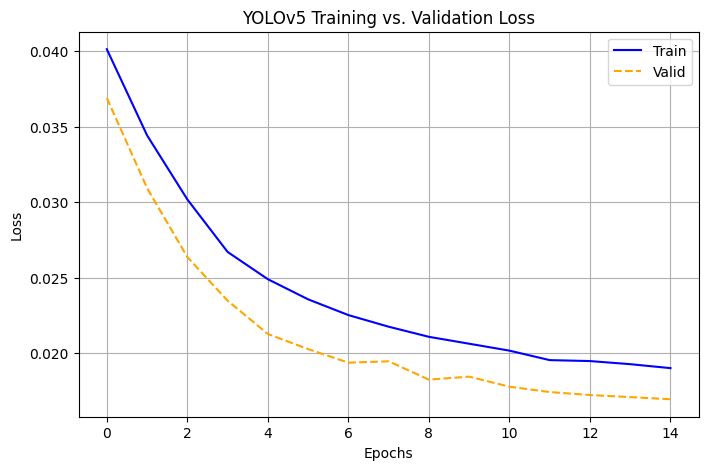

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Load YOLOv5 training results
results_path = "/kaggle/working/yolov5/runs/train/test_result/results.csv"  # Update path if needed
df = pd.read_csv(results_path)

# Extract relevant columns
epochs = df.index  # Epoch numbers
train_loss = df["      train/box_loss"]  # Training loss
val_loss = df["        val/box_loss"]  # Validation loss

# Plot training vs. validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train", color="blue", linestyle="-")
plt.plot(epochs, val_loss, label="Valid", color="orange", linestyle="--")

# Formatting
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("YOLOv5 Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()
